In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline


In [5]:
df = pd.read_csv('../data/raw/diabetes.csv)

SyntaxError: unterminated string literal (detected at line 1) (2513652720.py, line 1)

In [ ]:
df.head()
df.info()
df.describe()


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [ ]:
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

for col in cols_with_zero:
    df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.duplicated().sum()


np.int64(0)

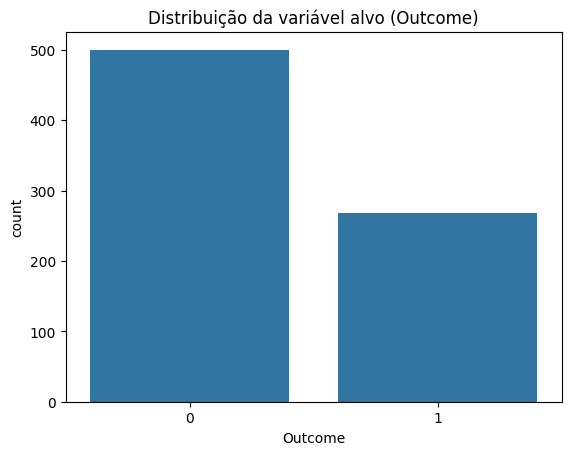

In [ ]:
df["Outcome"].value_counts()

sns.countplot(x="Outcome", data=df)
plt.title("Distribuição da variável alvo (Outcome)")
plt.show()


In [ ]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


<Axes: xlabel='Outcome', ylabel='Glucose'>

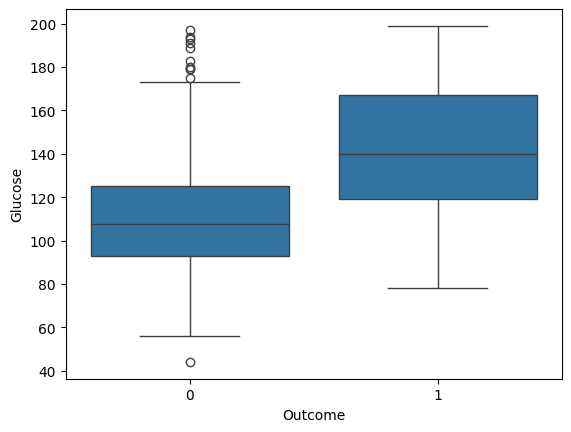

In [ ]:
sns.boxplot(x="Outcome", y="Glucose", data=df)

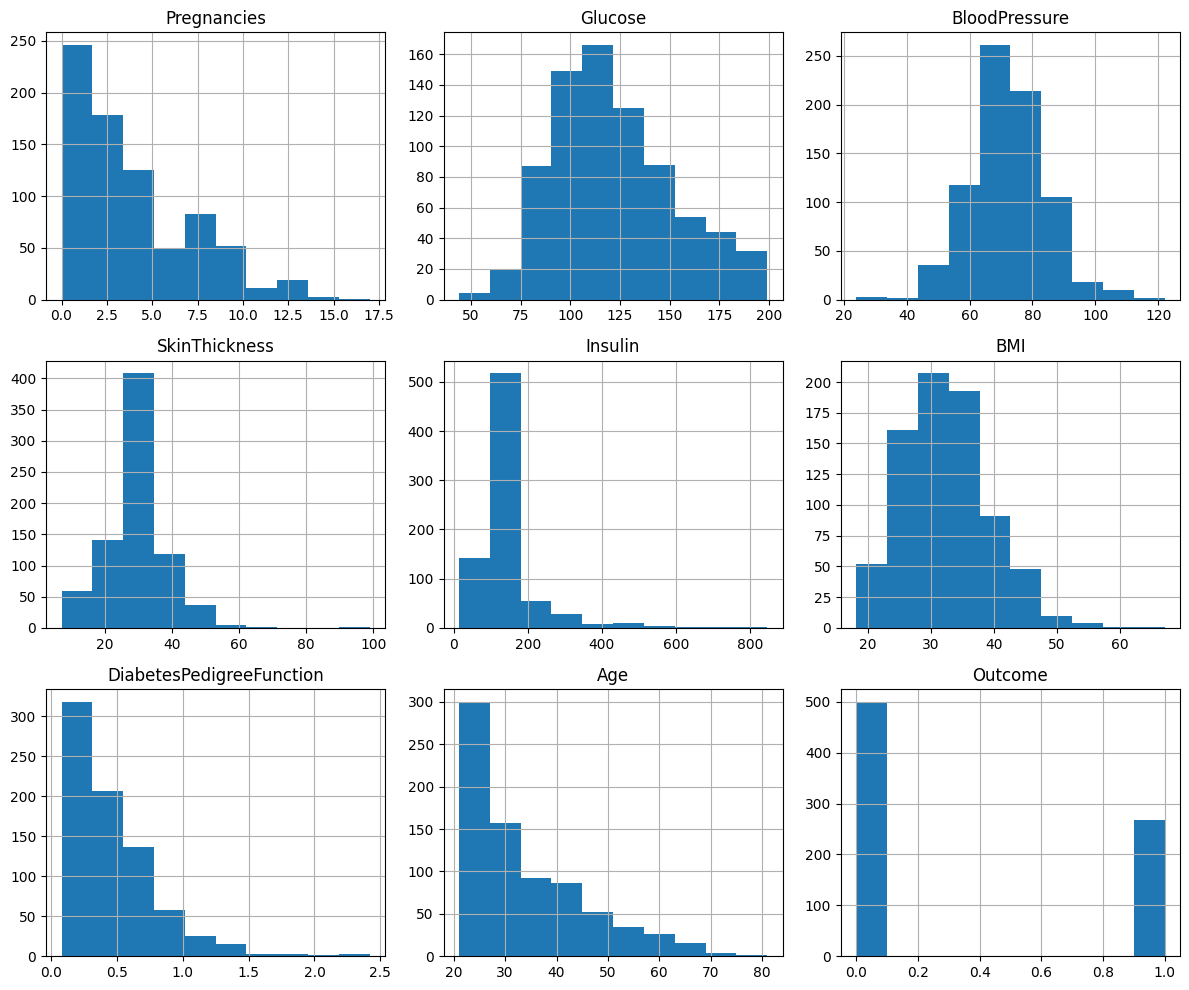

In [ ]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


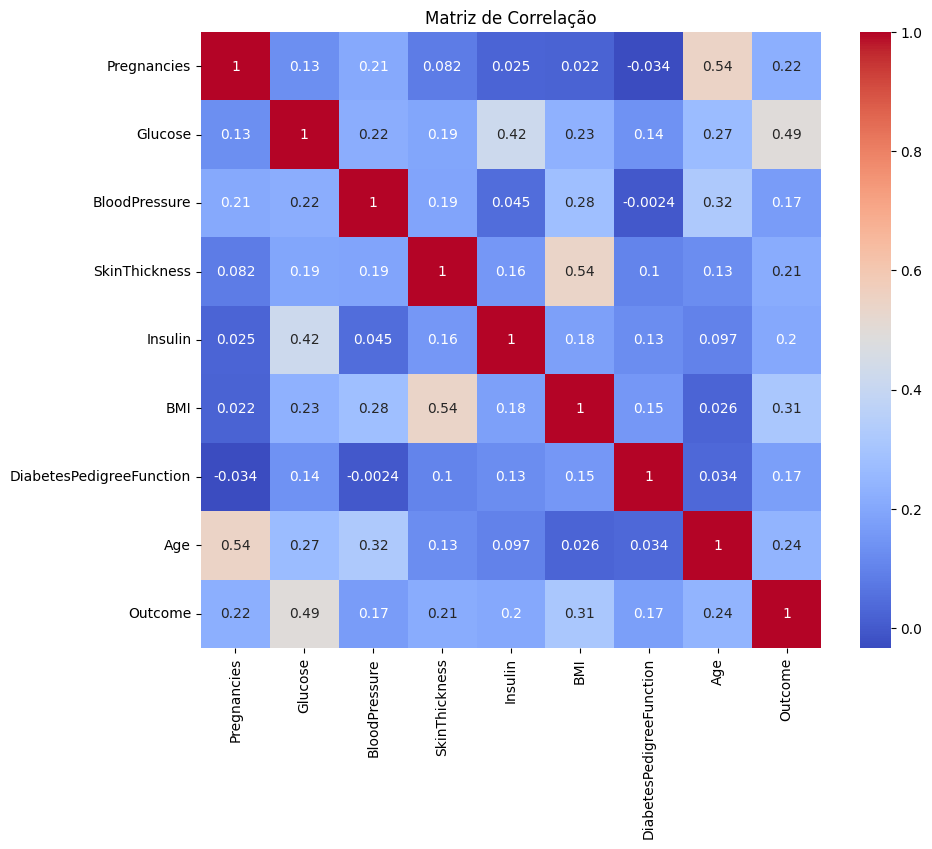

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()


In [ ]:
X, y = df.drop('Outcome', axis=1), df['Outcome']

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pipeline_sgd = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDClassifier(random_state=42))
]) 

In [ ]:
param_dist = {
    "sgd__loss": ["log_loss", "hinge"],
    "sgd__penalty": ["l2", "l1", "elasticnet"],
    "sgd__alpha": np.logspace(-4, -1, 50),
    "sgd__max_iter": [1000, 2000, 3000],
    "sgd__class_weight": [None, "balanced"]
}


random_search = RandomizedSearchCV(
    estimator=pipeline_sgd,
    param_distributions=param_dist,
    n_iter=30,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'sgd__alpha': array([0.0001..., 0.1 ]), 'sgd__class_weight': [None, 'balanced'], 'sgd__loss': ['log_loss', 'hinge'], 'sgd__max_iter': [1000, 2000, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strateg

In [ ]:
best_sgd_model = random_search.best_estimator_
random_search.best_params_

{'sgd__penalty': 'l1',
 'sgd__max_iter': 3000,
 'sgd__loss': 'hinge',
 'sgd__class_weight': 'balanced',
 'sgd__alpha': np.float64(0.00030888435964774815)}

In [ ]:
y_val_pred = best_sgd_model.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.91      0.64      0.75        75
           1       0.56      0.88      0.69        40

    accuracy                           0.72       115
   macro avg       0.74      0.76      0.72       115
weighted avg       0.79      0.72      0.73       115

